## FLAG-X workflow, unlabeled data

In this notebook we demonstrate how FLAG-X can be used to aid and accelerate manual gating of multiple samples. This can be used to efficiently obtain initial labels for the training of supervised classification models (such as MLP classifier and SOM classifier) for fully automated gating. For details, we refer to our preprint on [bioRxiv](https://doi.org/10.64898/2026.01.10.698765).

Here, only six exemplary samples from the BLAST110 dataset published by Mocking *et al.* (2025) (see: [Zenodo](https://zenodo.org/records/11046402), [DOI](https://doi.org/10.1038/s43856-024-00700-x)) to demonstrate the following workflow:

1. [Load data samples](#1-load-data-samples)
2. [Process data samples](#2-process-data-samples)
3. [SOM training](#3-som-training)
4. [Dimensionality reduction](#4-dimensionality-reduction)
5. [Export](#5-export)


### Import packages and define paths

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

from flagx.io import FlowDataManager
from flagx.gating import SOMClassifier
from flagx.dimred import UMAP, TSNE

plt.style.use('default')

BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data')
SAVE_PATH = os.path.join(BASE_DIR, 'results')
os.makedirs(SAVE_PATH, exist_ok=True)


### 1.) Data loading

In [2]:
# Instantiate the FlowDataManager
data_filenames = sorted([fn for fn in os.listdir(DATA_PATH) if fn.endswith('.fcs')])
fdm = FlowDataManager(
    data_file_names=data_filenames,
    data_file_path=DATA_PATH,
    save_path=None,
    verbosity=1
)

# Load the datafiles into memory; If present, use marker names (PnS) as index.
fdm.load_data_files_to_anndata(reindex=True)

# Harmonize channel names and order
mapping = {'CD34 Cy55': 'CD34', 'CD45 KO': 'CD45'}
for adata in fdm.anndata_list_:
    adata.var.index = adata.var.index.map(lambda x: mapping.get(x, x))
    spill = adata.uns['meta']['spill']
    spill.index = spill.index.to_series().replace(mapping)
    spill.columns = spill.columns.to_series().replace(mapping)
    adata.uns['meta']['spill'] = spill
common_channels = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45', 'Time', 'event_ID']
for i, adata in enumerate(fdm.anndata_list_):
    fdm.anndata_list_[i] = adata[:, common_channels].copy()


### 2.) Data processing

# Channel names:
['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45', 'Time', 'event_ID']



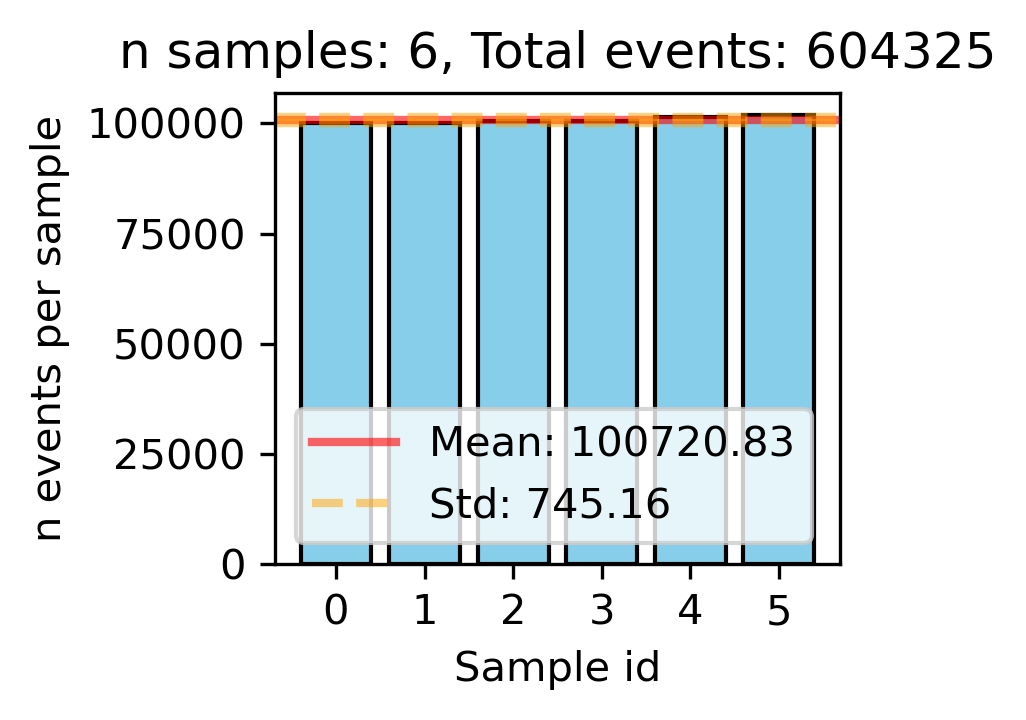

# Compensation log:
             filename                               logs
0  BLAST110_25_P1.fcs  compensation applied successfully
1  BLAST110_50_P1.fcs  compensation applied successfully
2  BLAST110_57_P1.fcs  compensation applied successfully
3  BLAST110_67_P1.fcs  compensation applied successfully
4  BLAST110_77_P1.fcs  compensation applied successfully
5  BLAST110_85_P1.fcs  compensation applied successfully


In [3]:

# Align channel names across samples, use 1st sample as reference
fdm.align_channel_names(reference_channel_names=0)

# Check whether channel names were consistent across all samples
fdm.check_og_channel_names_df()

adata = fdm.anndata_list_[0]
print(f'# Channel names:\n{adata.var.index.tolist()}\n')

# Check the sample sizes
fdm.check_sample_sizes()
fig, ax = plt.subplots(figsize=(3, 2.5), dpi=300)
fdm.plot_sample_size_df(sample_size_df=fdm.sample_sizes_, ax=ax)
fig.tight_layout()
plt.show()
plt.close(fig)

# Apply compensation
fdm.sample_wise_compensation()
print(f'# Compensation log:\n{fdm.compensation_log_}')

# Downsample to 5000 events per sample (for faster training, one should use more in practice)
downsampling_bools, _ = fdm.sample_wise_downsampling(data_set='all', target_num_events=100, stratified=False)  # Todo

# Apply preprocessing transformation, choose arcsinh with a cofactor of 150, save non-transformed data to layer 'raw'
fdm.sample_wise_preprocessing(flavour='arcsinh', save_raw_to_layer='raw', cofactor=150)


### 3.) SOM training
Train the SOM component of the SOM classifier (unsupervised)

In [4]:
# Extract data concatenated data matrix for model training
channels = ['FSC-A', 'SSC-A', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45']
data_loader = fdm.get_data_loader(
    data_set='all',
    channels=channels,
    batch_size=-1,
    shuffle=True,
    return_data_loader='np_array',
)
x_train = next(iter(data_loader))

# Create dummy label vector
y_train = np.full(x_train.shape[0], -999)

# Instantiate the SOM classifer
som_clf = SOMClassifier(
    som_topology='planar',
    som_grid_type='rectangular',
    som_dimensions=(10, 10),
    neighborhood='gaussian',
    gaussian_neighborhood_sigma=0.1,
    initialization='pca',
    n_epochs=20,
    radius_0=-0.5,
    radius_n=0.1,
    radius_cooling='exponential',
    learning_rate_0=0.1,
    learning_rate_n=0.001,
    learning_rate_decay='exponential',
    unlabeled_label=-999,
    verbosity=1
)

som_clf.fit(X=x_train, y=y_train)




    100% [===================================================]


Time for epoch 1: 0.07086 Time for epoch 2: 0.04775 Time for epoch 3: 0.0346 Time for epoch 4: 0.04476 Time for epoch 5: 0.04487 Time for epoch 6: 0.0421 Time for epoch 7: 0.02633 Time for epoch 8: 0.02889 Time for epoch 9: 0.01575 Time for epoch 10: 0.02085 Time for epoch 11: 0.0137 Time for epoch 12: 0.01967 Time for epoch 13: 0.01016 Time for epoch 14: 0.01202 Time for epoch 15: 0.008927 Time for epoch 16: 0.004413 Time for epoch 17: 0.004186 Time for epoch 18: 0.002352 Time for epoch 19: 0.003394 Time for epoch 20: 0.002347 /mnt/c/Users/paulm/PycharmProjects/FLAG-X/flagx/gating/som_classifier.py:230: UserWarning: No labeled data provided. Only the SOM component is trained in an unsupervised fashion.
  warnings.warn(


,som_topology,'planar'
,som_grid_type,'rectangular'
,som_dimensions,"(10, ...)"
,neighborhood,'gaussian'
,gaussian_neighborhood_sigma,0.1
,initialization,'pca'
,initial_codebook,None
,n_epochs,20
,radius_0,5.0
,radius_n,0.1
,radius_cooling,'exponential'


### 4.) Dimensionality reduction

In [5]:

# Extract data matrices without shuffling and keep track of sample IDs
data_matrices = []
sample_ids = []
for i, adata in enumerate(fdm.anndata_list_):
    data_matrices.append(adata[:, channels].X.copy())
    sample_ids.append(np.full(adata.shape[0], i))
x_ordered = np.concatenate(data_matrices, axis=0)
y_sample_id = np.concatenate(sample_ids, axis=0)

_, x_som, _, _ = som_clf.transform(x_ordered)

reducer_umap = UMAP(n_components=2, n_jobs=-1)
x_umap = reducer_umap.fit_transform(x_ordered)

reducer_tsne = TSNE(n_components=2, n_jobs=-1)
x_tsne = reducer_tsne.fit_transform(x_ordered)


### 5.) Export

In [ ]:
# Todo

### Load and process annotation data for visualization
Population labels were provided by Mocking *et al.* (2025) (see: [Zenodo](https://zenodo.org/records/11046402), [DOI](https://doi.org/10.1038/s43856-024-00700-x)).

In [6]:
# Load annotation data with blast labels
label_dfs = []
for fn in data_filenames:
    label_df = pd.read_csv(os.path.join(DATA_PATH, fn[:-4]+ '.csv'), index_col=0)
    label_dfs.append(label_df)

# Downsample and extract blast annotations from annotation dataframes
y_blasts = []  # WBC, CD45dim, CD34pos or CD117pos
y_wbc_cd45dims = []
y_wbc_cd45dim_cd34positives = []
y_wbc_cd45dim_cd117positives = []
for i, (ds_bool, label_df) in enumerate(zip(downsampling_bools, label_dfs)):
    y_blasts.append(label_df['Blast'].to_numpy()[ds_bool])
    y_wbc_cd45dims.append(label_df['WBC/CD45dim'].to_numpy()[ds_bool])
    y_wbc_cd45dim_cd34positives.append(label_df['WBC/CD45dim/CD34pos'].to_numpy()[ds_bool])
    y_wbc_cd45dim_cd117positives.append(label_df['WBC/CD45dim/CD117pos'].to_numpy()[ds_bool])

y_blast = np.concatenate(y_blasts)
y_wbc_cd45dim = np.concatenate(y_wbc_cd45dims)
y_wbc_cd45dim_cd34pos = np.concatenate(y_wbc_cd45dim_cd34positives)
y_wbc_cd45dim_cd117pos = np.concatenate(y_wbc_cd45dim_cd117positives)


### Visualize results in Python

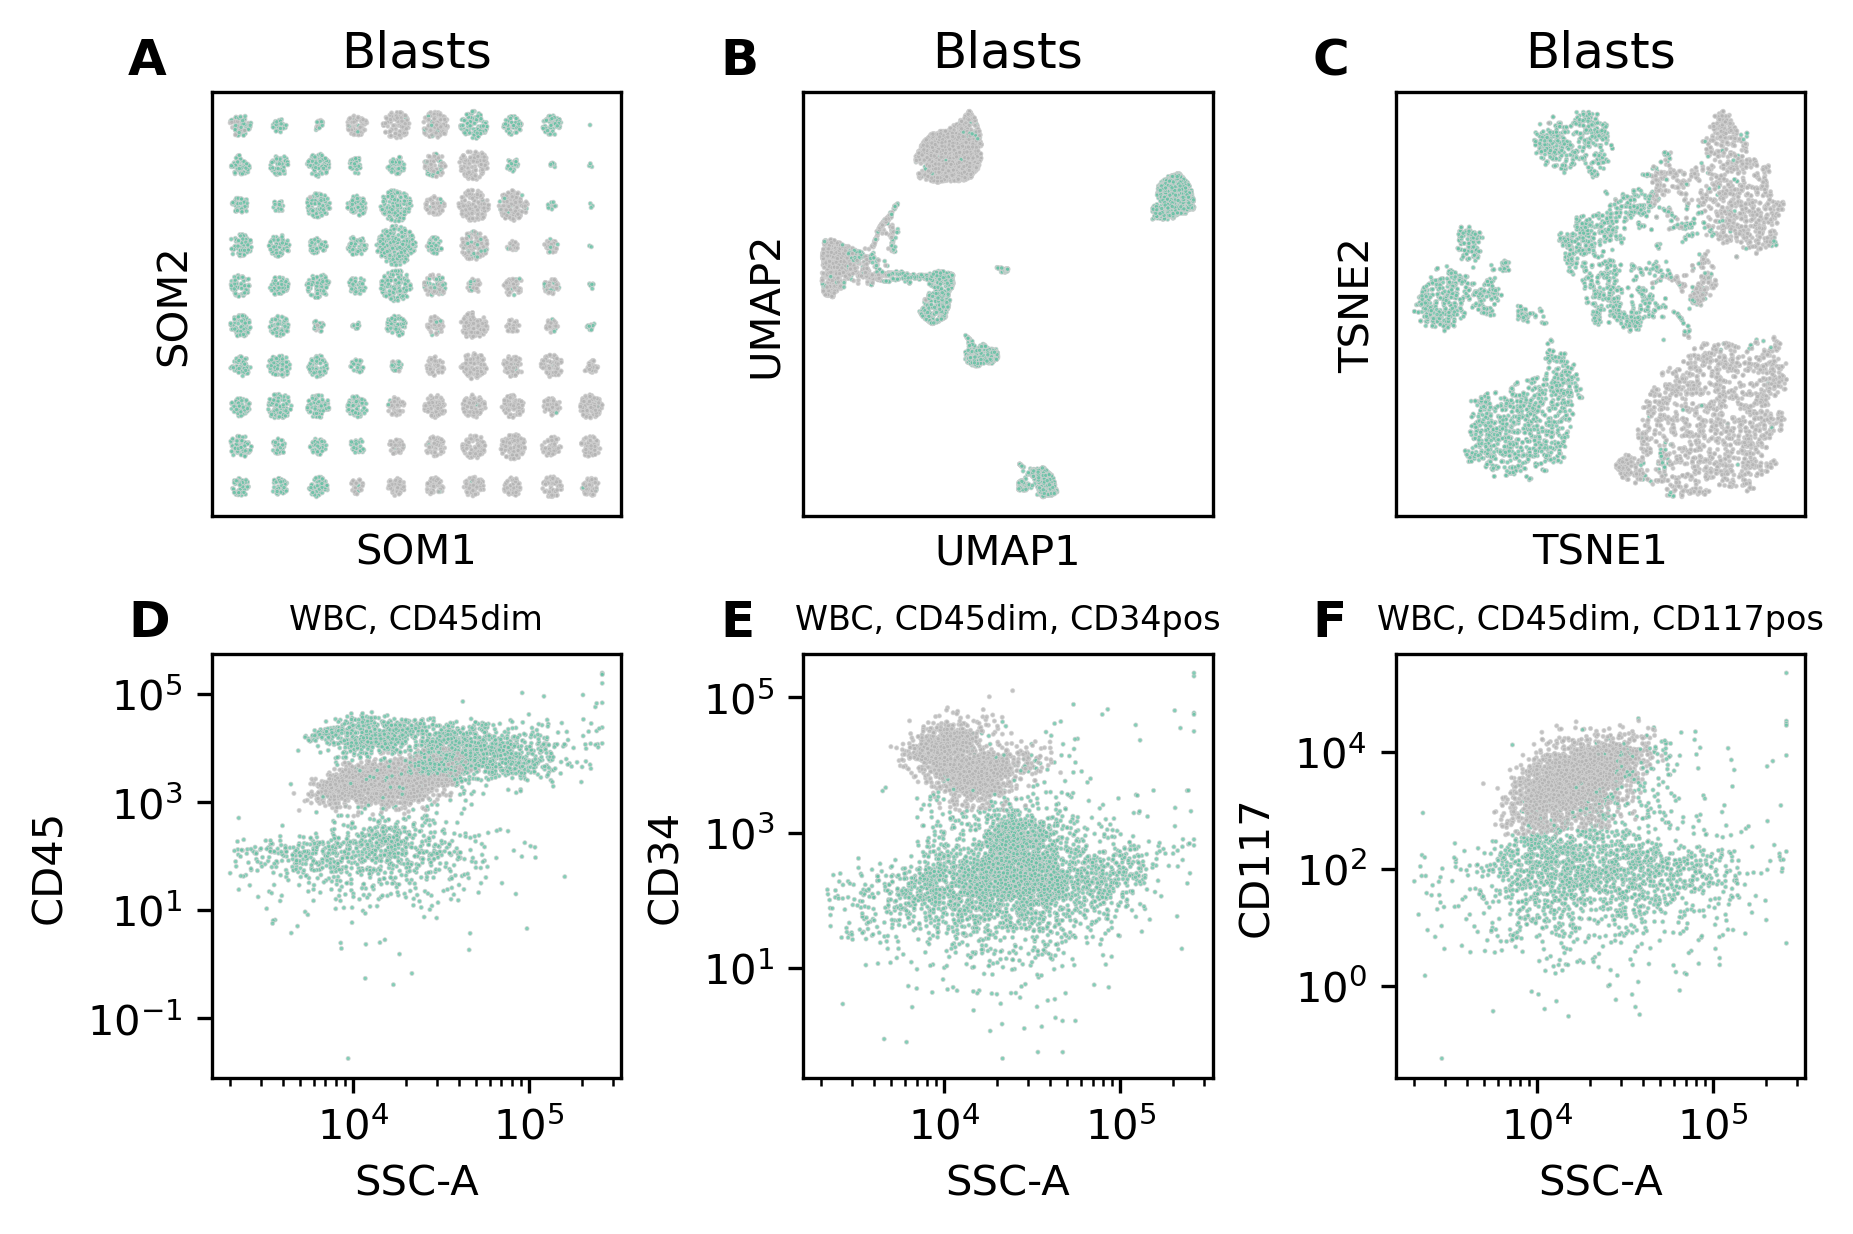

In [7]:
# Extract raw data matrices for marker scatter plots
data_matrices_raw = []
sample_ids = []
for i, adata in enumerate(fdm.anndata_list_):
    data_matrices.append(adata[:, channels].X.copy())
    data_matrices_raw.append(adata[:, channels].layers['raw'].copy())
    sample_ids.append(np.full(adata.shape[0], i))
x_ordered = np.concatenate(data_matrices, axis=0)
x_ordered_raw = np.concatenate(data_matrices_raw, axis=0)
y_sample_id = np.concatenate(sample_ids, axis=0)

x_plot = pd.DataFrame(x_ordered_raw, columns=channels)

fig, axd = plt.subplot_mosaic(
    '''
    ABC
    DEF
    ''',
    figsize=(6, 4),
    dpi=300,
    constrained_layout=True,
)

marker_size = 1.0

for key, name, x in zip(list('ABC'), ['SOM', 'UMAP', 'TSNE'], [x_som, x_umap, x_tsne]):

    ax = axd[key]
    ax.scatter(
        x[:, 0],
        x[:, 1],
        s=marker_size,
        c=y_blast,
        cmap='Set2',
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
    )
    ax.set_xlabel(f'{name}1')
    ax.set_ylabel(f'{name}2')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Blasts')

# 'FSC-A', 'SSC-A', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45 KO'
marker_combinations = [('SSC-A', 'CD45'), ('SSC-A', 'CD34'), ('SSC-A', 'CD117')]
y_cols = [y_wbc_cd45dim, y_wbc_cd45dim_cd34pos, y_wbc_cd45dim_cd117pos]
titles = ['WBC, CD45dim', 'WBC, CD45dim, CD34pos', 'WBC, CD45dim, CD117pos']

for key, (marker0, marker1), y_col, title in zip(list('DEF'), marker_combinations, y_cols, titles):
    ax = axd[key]
    ax.scatter(
        x_plot[marker0].to_numpy(),
        x_plot[marker1].to_numpy(),
        s=marker_size,
        c=y_col,
        cmap='Set2',
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
    )
    ax.set_xlabel(marker0)
    ax.set_ylabel(marker1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(False)
    ax.set_title(title, fontsize=8)

for label, ax in axd.items():
    trans = mtransforms.ScaledTranslation(-20 / 72, 7 / 72, fig.dpi_scale_trans)
    ax.text(0.0, 0.95, label, transform=ax.transAxes + trans, fontsize=12, va='bottom', fontfamily='sans-serif', fontweight='bold')

plt.show()
